In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

llc = xr.open_zarr('/orcd/data/abodner/003/LLC4320/LLC4320',consolidated=False)

<>:55: SyntaxWarning: invalid escape sequence '\c'
<>:56: SyntaxWarning: invalid escape sequence '\c'
<>:55: SyntaxWarning: invalid escape sequence '\c'
<>:56: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_2500472/234563483.py:55: SyntaxWarning: invalid escape sequence '\c'
  ax.set_xlabel('Longitude ($^\circ$)', fontsize=12)
/tmp/ipykernel_2500472/234563483.py:56: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel('Latitude ($^\circ$)', fontsize=12)


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

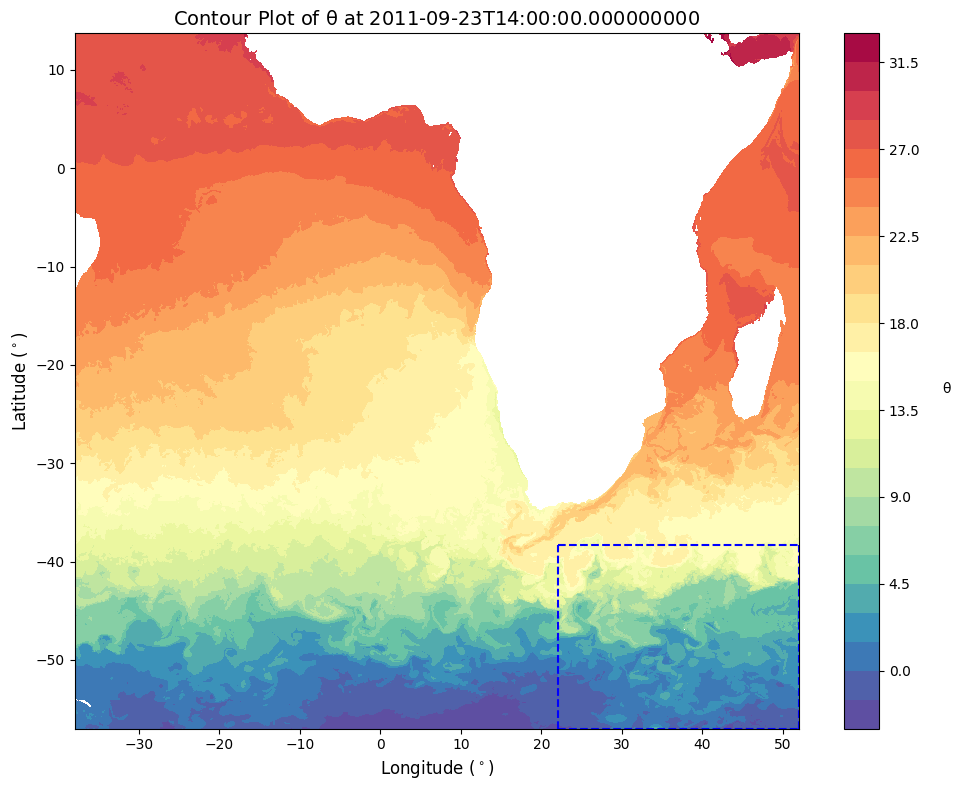

In [3]:
import matplotlib.pyplot as plt
import numpy as np

llc_sub = llc.isel(face=1, k = 0, time = 254)

# Assuming llc and llc_sub are defined and contain the necessary data

# Extract latitude and longitude for the current face (e.g., face 1)
lat = llc['YC'].sel(face=1)
lon = llc['XC'].sel(face=1)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Contour plot using lat and lon
cf = ax.contourf(
    lon,  # Use longitude for x-axis
    lat,  # Use latitude for y-axis
    llc_sub['Theta'],
    cmap="Spectral_r",
    vmin=np.min(llc_sub['Theta']).values,
    vmax=np.max(llc_sub['Theta']).values,
    levels=30
)

# Define regions in terms of i and j indices
i_0, i_1 = 2880, 4319
j_0, j_1 = 0, 1440
# k_0, k_1 = 2480, 2840
# l_0, l_1 = 1150, 1510

# Convert index limits to lat/lon limits for the "Agulhas Patch"
x_min, x_max = lon[0, 1080], lon[0, 1080 + 2160]
y_min, y_max = lat[0, 0], lat[2160, 0]

# Plot lines for regions using lat/lon
ax.hlines(y=lat[j_0, i_0], xmin=lon[j_0, i_0], xmax=lon[j_0, i_1], colors='b', linestyles='dashed')
ax.hlines(y=lat[j_1, i_0], xmin=lon[j_1, i_0], xmax=lon[j_1, i_1], colors='b', linestyles='dashed')
ax.vlines(x=lon[j_0, i_0], ymin=lat[j_0, i_0], ymax=lat[j_1, i_0], colors='b', linestyles='dashed')
ax.vlines(x=lon[j_0, i_1], ymin=lat[j_0, i_1], ymax=lat[j_1, i_1], colors='b', linestyles='dashed')

# ax.hlines(y=lat[l_0, k_0], xmin=lon[l_0, k_0], xmax=lon[l_0, k_1], colors='g', linestyles='dashed')
# ax.hlines(y=lat[l_1, k_0], xmin=lon[l_1, k_0], xmax=lon[l_1, k_1], colors='g', linestyles='dashed')
# ax.vlines(x=lon[l_0, k_0], ymin=lat[l_0, k_0], ymax=lat[l_1, k_0], colors='g', linestyles='dashed')
# ax.vlines(x=lon[l_0, k_1], ymin=lat[l_0, k_1], ymax=lat[l_1, k_1], colors='g', linestyles='dashed')

# Add colorbar
cbar = plt.colorbar(cf, ax=ax)
cbar.set_label(r'$\theta$', rotation=0, labelpad=20)

# Get the time value and format it as a string
time_str = str(llc_sub.time.values)

# Set labels and title with the date
ax.set_xlabel('Longitude ($^\circ$)', fontsize=12)
ax.set_ylabel('Latitude ($^\circ$)', fontsize=12)
ax.set_title(f'Contour Plot of $\\theta$ at {time_str}', fontsize=14)

# Set limits using the converted lat/lon values for the "Agulhas Patch"
# ax.set_xlim(x_min, x_max)
# ax.set_ylim(y_min, y_max)

# Layout
plt.tight_layout()

# Save and show
# plt.savefig("JonesRegions_latlonfull.png", dpi=400, bbox_inches='tight')
plt.show()

/orcd/home/002/benamran/.conda/envs/my_env/lib/python3.12/site-packages/dask/array/reductions.py:325: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/tmp/ipykernel_3914683/299016537.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


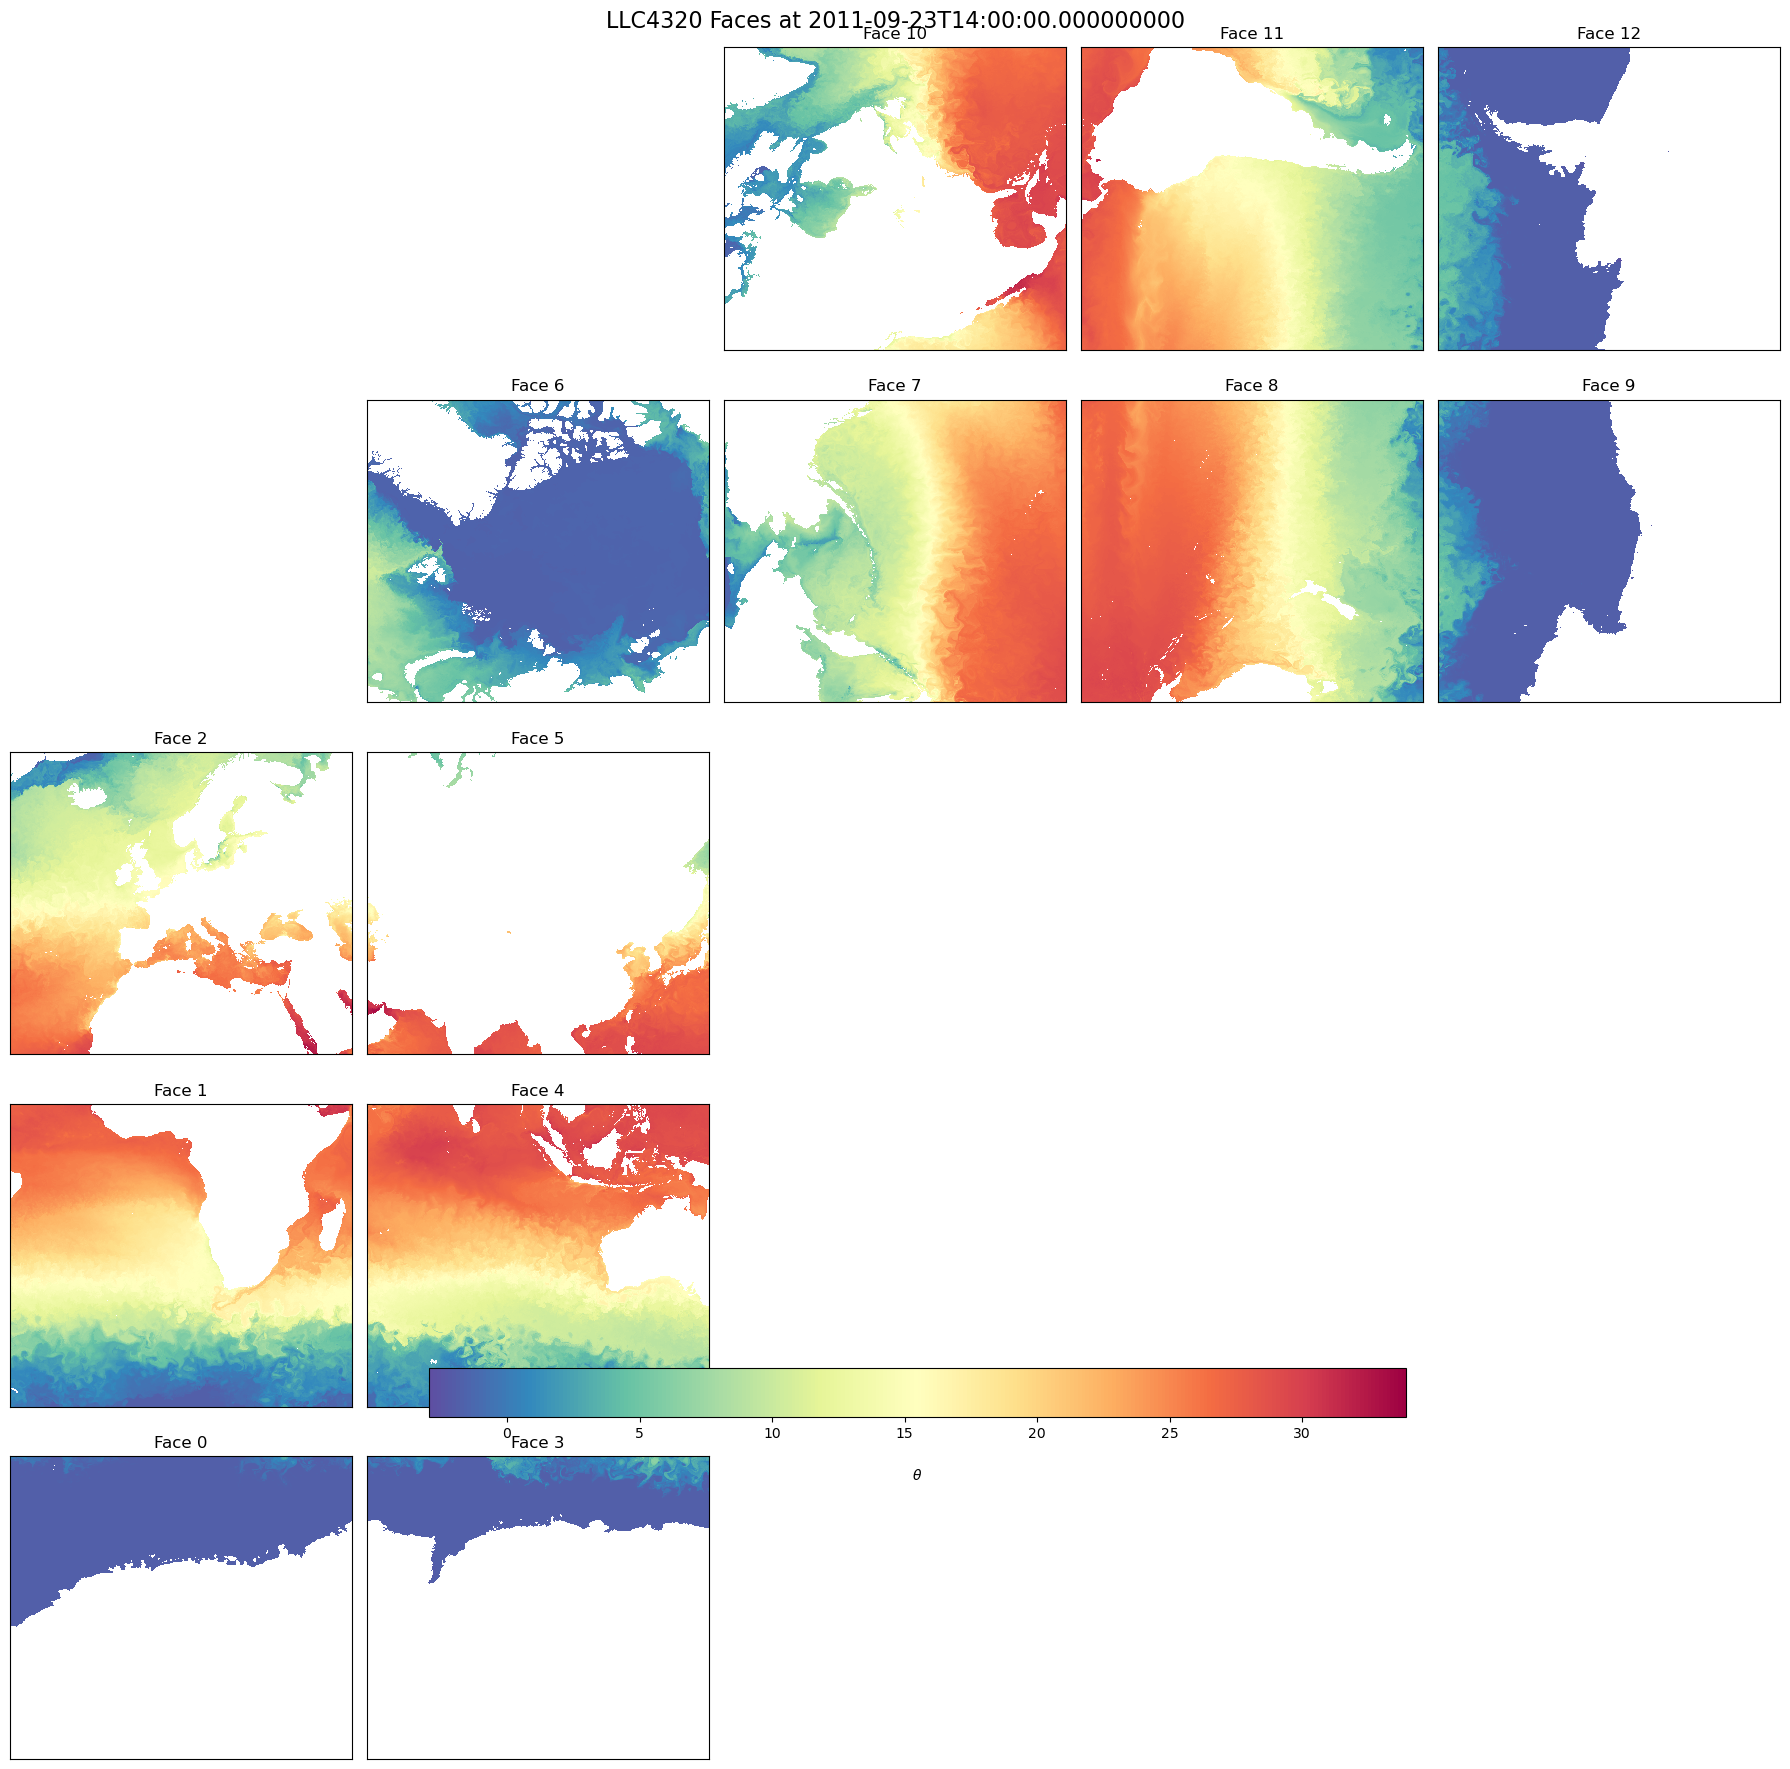

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Select one timestep and depth level
llc_sub = llc.isel(k=0, time=254)

# 5x5 LLC-style layout
# Grid positions are (row, col)

layout = {
    0:  (4, 0),
    1:  (3, 0),
    2:  (2, 0),
    3:  (4, 1),
    4:  (3, 1),
    5:  (2, 1),
    6:  (1, 1),
    7:  (1, 2),
    8:  (1, 3),
    9:  (1, 4),
    10: (0, 2),
    11: (0, 3),
    12: (0, 4),
}

fig, axes = plt.subplots(5, 5, figsize=(18, 18))

# Turn everything off initially
for ax_row in axes:
    for ax in ax_row:
        ax.axis('off')

# Global color limits
vmin = llc_sub['Theta'].min().values
vmax = llc_sub['Theta'].max().values

# Plot each face
for face in range(13):

    row, col = layout[face]
    ax = axes[row, col]

    ax.axis('on')

    theta = llc_sub['Theta'].sel(face=face)

    pcm = ax.pcolormesh(
        theta,
        cmap='Spectral_r',
        vmin=vmin,
        vmax=vmax,
        shading='auto'
    )

    ax.set_title(f'Face {face}', fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

# Shared colorbar
cbar = fig.colorbar(
    pcm,
    ax=axes,
    shrink=0.7,
)

cbar.set_label(r'$\theta$', rotation=0, labelpad=20)

# Time label
time_str = str(llc_sub.time.values)
fig.suptitle(f'LLC4320 Faces at {time_str}', fontsize=16)

plt.tight_layout()
plt.show()

/orcd/home/002/benamran/.conda/envs/my_env/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


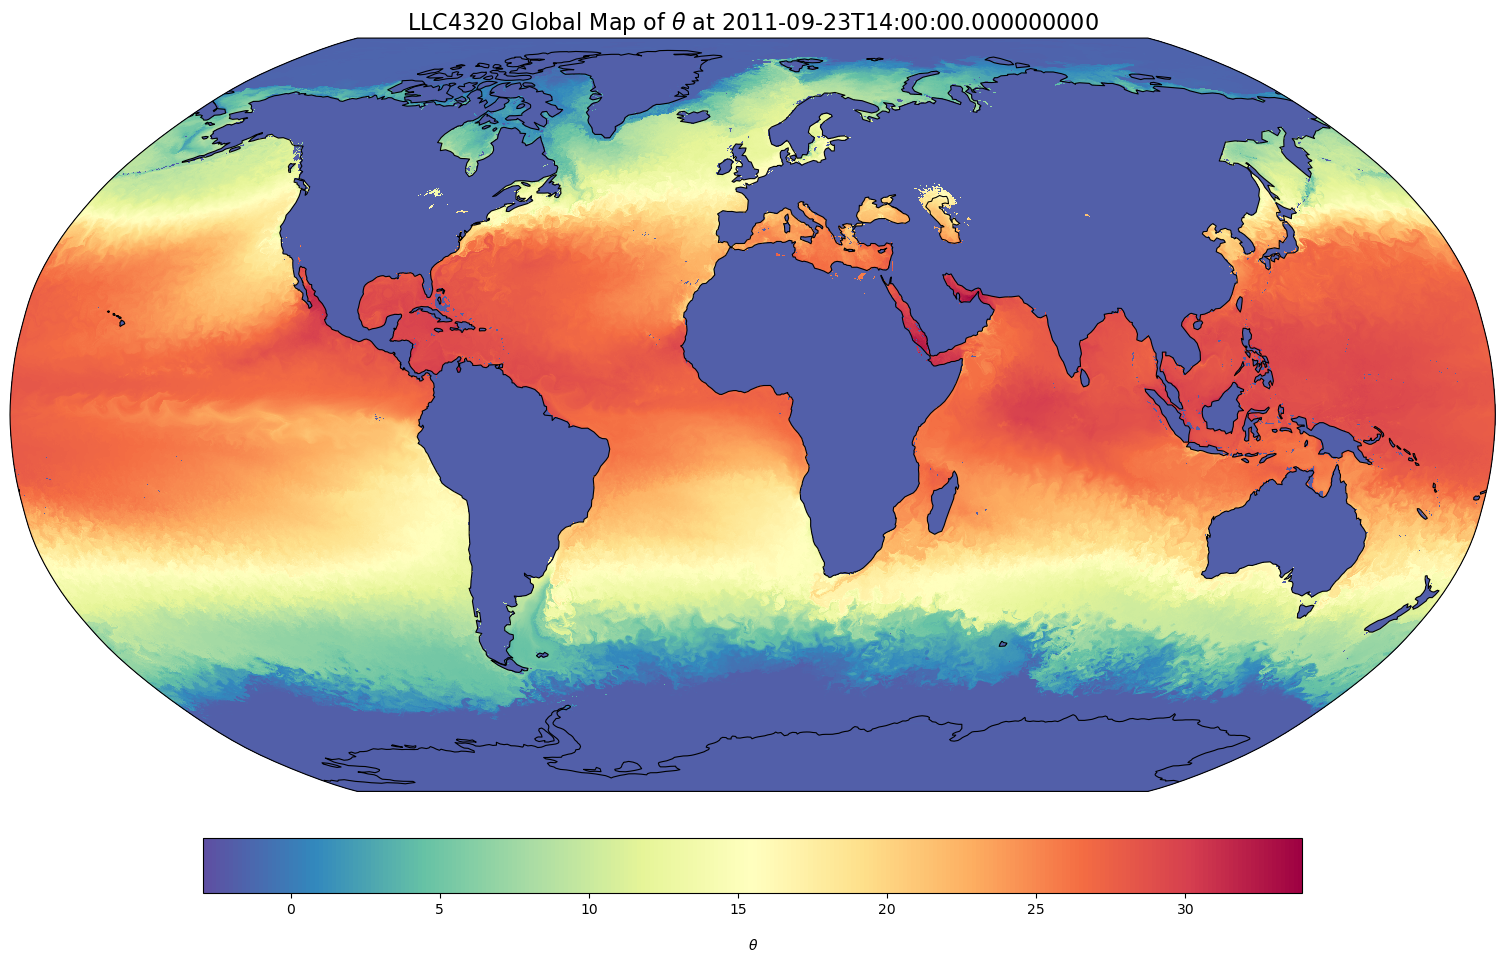

In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

# Select timestep and depth
llc_sub = llc.isel(k=0, time=254)

# Global color limits
vmin = llc_sub['Theta'].min().values
vmax = llc_sub['Theta'].max().values

# Create global map
fig = plt.figure(figsize=(16, 10))

ax = plt.axes(projection=ccrs.Robinson())

# Optional map features
ax.coastlines(linewidth=0.8)
ax.set_global()

# Plot all 13 LLC faces
for face in range(13):

    # Extract face data
    theta = llc_sub['Theta'].sel(face=face)
    lon = llc['XC'].sel(face=face)
    lat = llc['YC'].sel(face=face)

    # Plot onto map projection
    pcm = ax.pcolormesh(
        lon,
        lat,
        theta,
        transform=ccrs.PlateCarree(),
        cmap='Spectral_r',
        shading='auto',
        vmin=vmin,
        vmax=vmax,
        rasterized=True
    )

# Colorbar
cbar = plt.colorbar(
    pcm,
    ax=ax,
    orientation='horizontal',
    pad=0.05,
    shrink=0.7
)

cbar.set_label(r'$\theta$', rotation=0, labelpad=15)

# Title
time_str = str(llc_sub.time.values)

ax.set_title(
    f'LLC4320 Global Map of $\\theta$ at {time_str}',
    fontsize=16
)

plt.tight_layout()
plt.show()

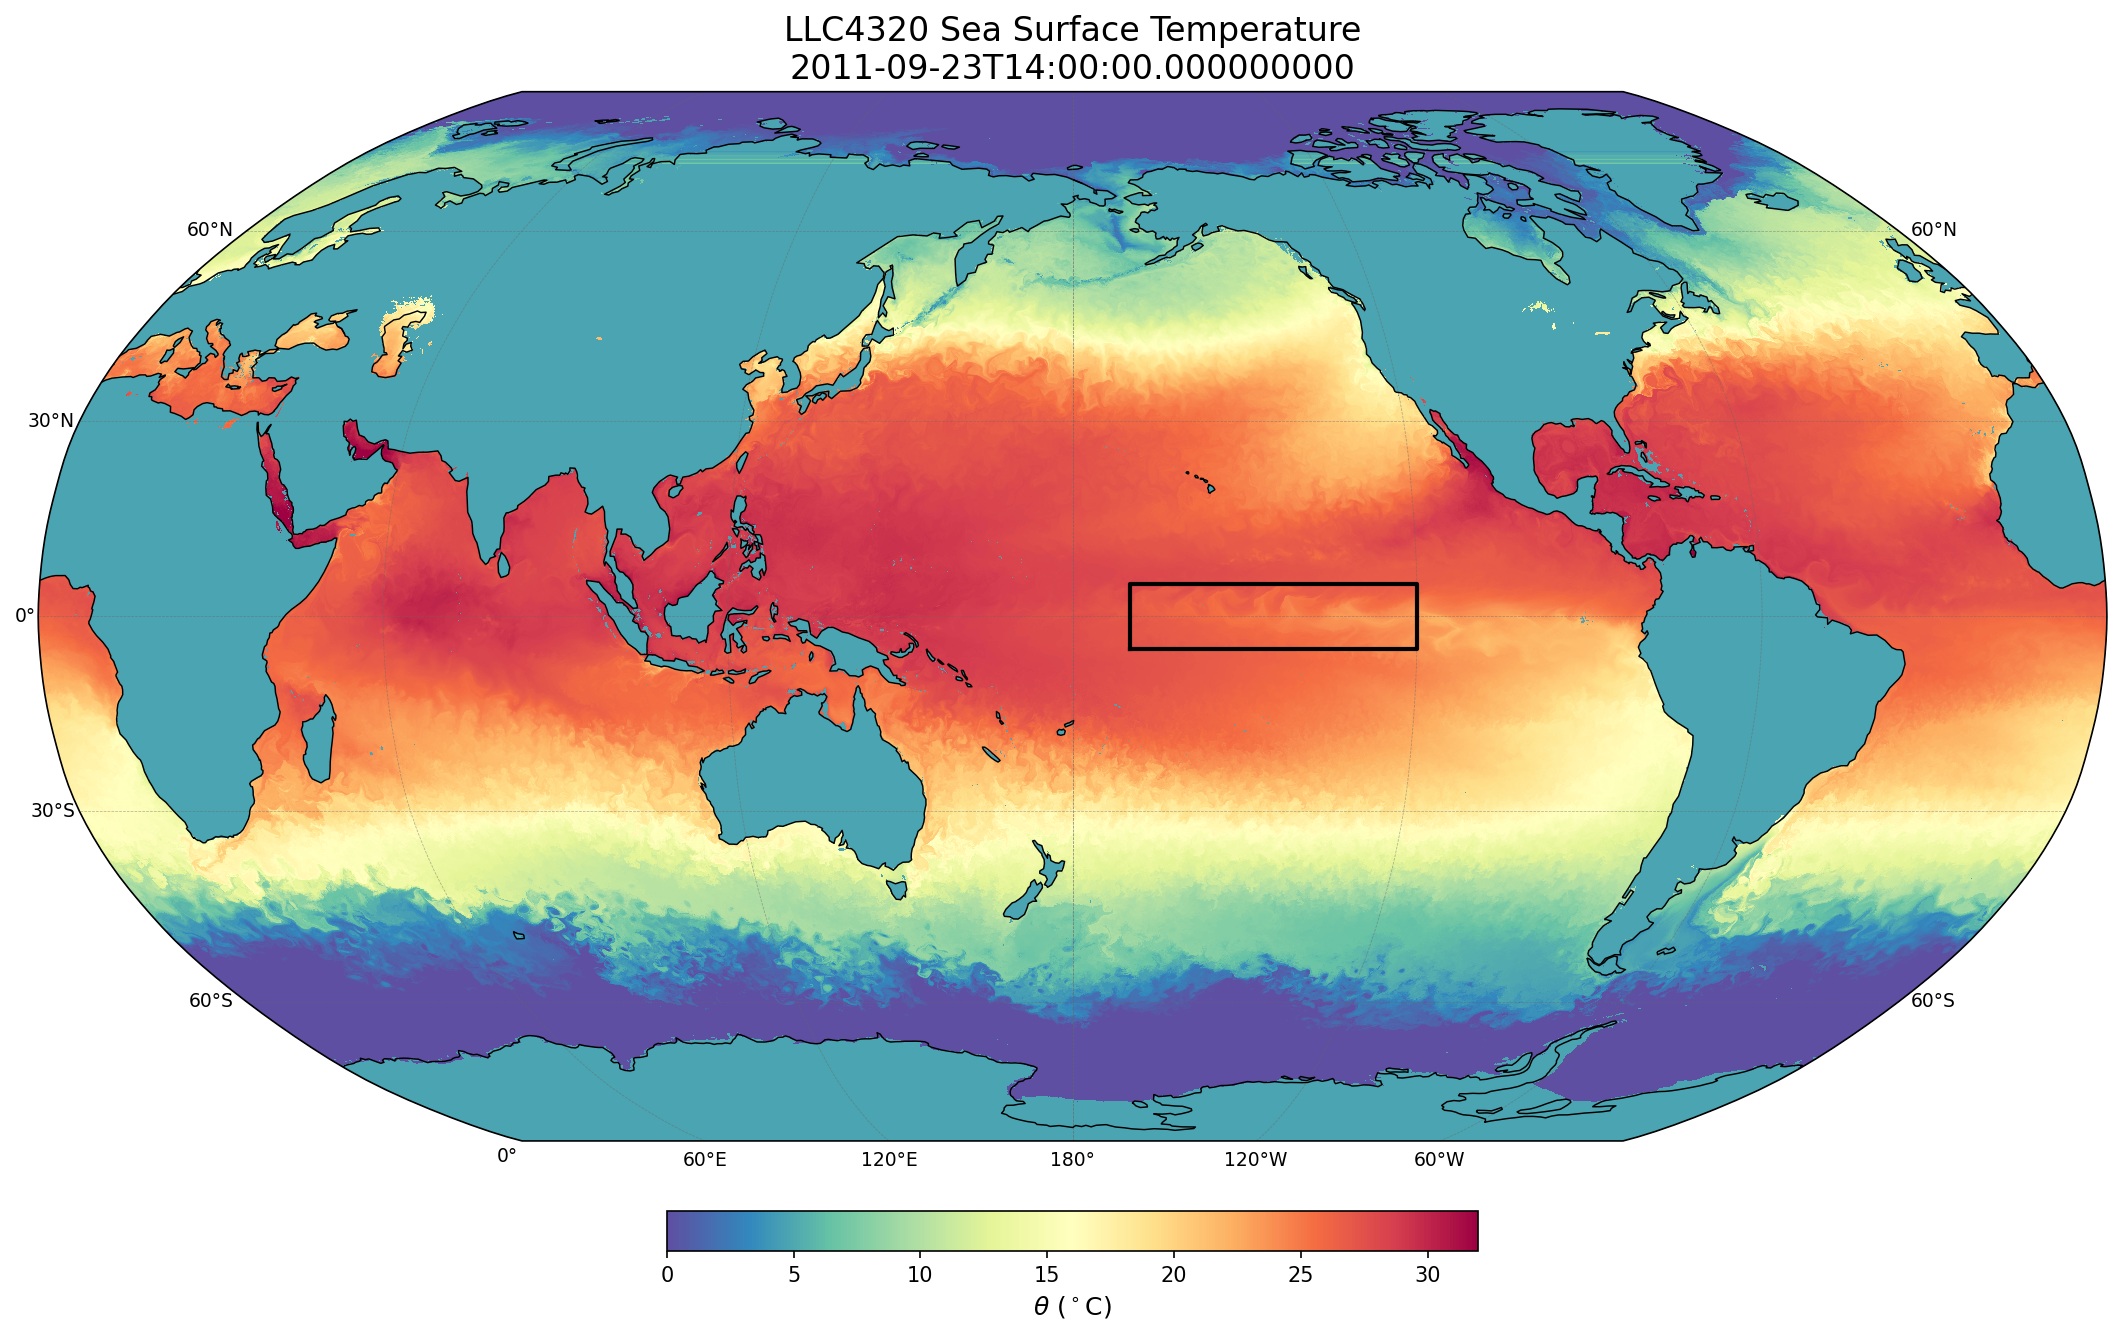

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ============================================
# Select timestep and surface level
# ============================================

llc_sub = llc.isel(
    time=254,
    k=0
)

# ============================================
# Variables
# ============================================

theta = llc_sub["Theta"]

xc = llc["XC"]
yc = llc["YC"]

# Surface wet mask
mask = llc["hFacC"].isel(k=0)

# ============================================
# Color limits
# ============================================

vmin = 0
vmax = 32

# ============================================
# Colormap
# NaNs fully transparent
# ============================================

cmap = plt.cm.Spectral_r.copy()
cmap.set_bad(alpha=0)

# ============================================
# Projection setup
# Pacific-centered Robinson
# ============================================

proj = ccrs.Robinson(
    central_longitude=180
)

data_crs = ccrs.PlateCarree()

# ============================================
# Figure setup
# ============================================

fig = plt.figure(figsize=(16, 9), dpi=150)

ax = plt.axes(projection=proj)

ax.set_global()

# Background ocean color
ax.set_facecolor("white")

# White land underneath data
ax.add_feature(
    cfeature.LAND,
    facecolor="white",
    edgecolor="none",
    zorder=0
)

# Coastlines
ax.coastlines(
    linewidth=0.7,
    color="black",
    zorder=5
)

# ============================================
# Plot LLC faces
# ============================================

pcm = None

for face in range(13):

    # Extract surface temperature
    theta_face = theta.sel(face=face)

    # Apply ocean mask
    theta_face = theta_face.where(
        mask.sel(face=face) > 0
    )

    # Coordinates
    lon_face = xc.sel(face=face)
    lat_face = yc.sel(face=face)

    # Shift longitudes to [0,360]
    lon_face = (lon_face + 360) % 360

    # Plot
    pcm = ax.pcolormesh(
        lon_face,
        lat_face,
        theta_face,
        transform=data_crs,
        cmap=cmap,
        shading="auto",
        rasterized=True,
        vmin=vmin,
        vmax=vmax,
        zorder=1
    )

# ============================================
# Gridlines
# ============================================

gl = ax.gridlines(
    crs=data_crs,
    draw_labels=True,
    linewidth=0.35,
    color="0.4",
    alpha=0.5,
    linestyle="--"
)

gl.top_labels = False
gl.right_labels = False

gl.xlocator = mticker.FixedLocator(
    np.arange(-180, 181, 60)
)

gl.ylocator = mticker.FixedLocator(
    np.arange(-90, 91, 30)
)

gl.xlabel_style = {"size": 9}
gl.ylabel_style = {"size": 9}

# ============================================
# Niño 3.4 box
# ============================================

ax.plot(
    [-170, -120, -120, -170, -170],
    [-5, -5, 5, 5, -5],
    transform=data_crs,
    color="black",
    linewidth=2,
    zorder=6
)

# ============================================
# Colorbar
# ============================================

cbar = fig.colorbar(
    pcm,
    ax=ax,
    orientation="horizontal",
    pad=0.06,
    shrink=0.7,
    fraction=0.035
)

cbar.set_label(
    r'$\theta$ ($^\circ$C)',
    fontsize=12
)

# ============================================
# Title
# ============================================

time_str = str(llc_sub.time.values)

ax.set_title(
    f"LLC4320 Sea Surface Temperature\n{time_str}",
    fontsize=16
)

# ============================================
# Show figure
# ============================================

plt.tight_layout()

plt.show()

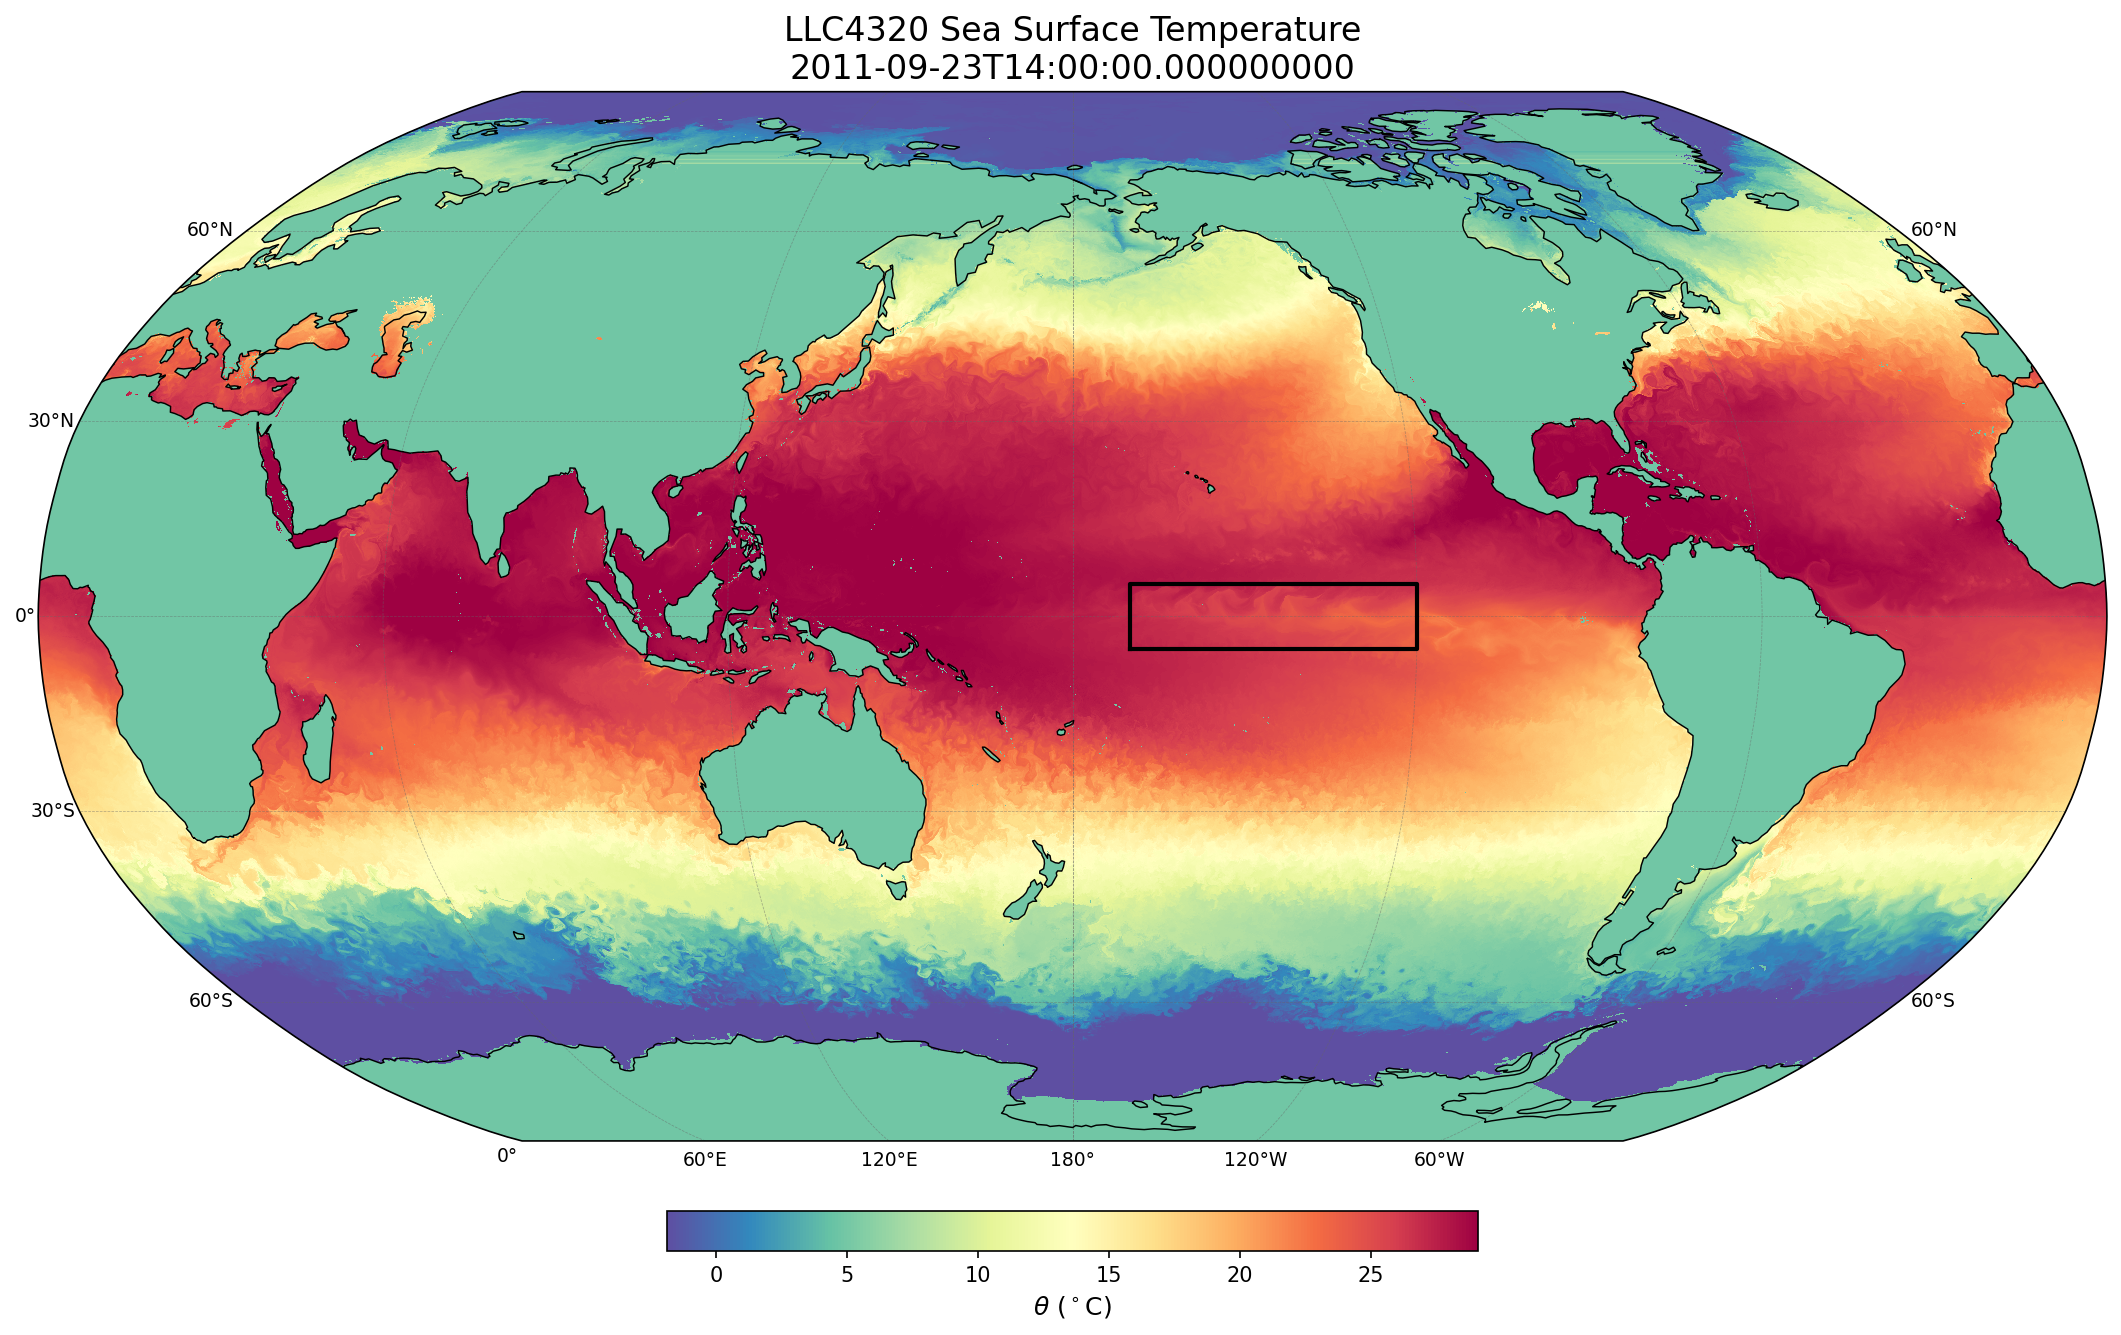

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
# ============================================
# Select timestep and surface level
# ============================================
llc_sub = llc.isel(
    time=254,
    k=0
)
# ============================================
# Variables
# ============================================
theta = llc_sub["Theta"]
xc = llc["XC"]
yc = llc["YC"]
# Surface wet mask
mask = llc["hFacC"].isel(k=0)
# ============================================
# Color limits — 2nd and 98th percentile
# ============================================
all_vals = []
for face in range(13):
    theta_face = theta.sel(face=face)
    theta_face = theta_face.where(mask.sel(face=face) > 0)
    vals = theta_face.values.ravel()
    all_vals.append(vals[~np.isnan(vals)])
all_vals = np.concatenate(all_vals)
vmin = float(np.percentile(all_vals, 2))
vmax = float(np.percentile(all_vals, 98))
# ============================================
# Colormap
# NaNs fully transparent
# ============================================
cmap = plt.cm.Spectral_r.copy()
cmap.set_bad(alpha=0)
# ============================================
# Projection setup
# Pacific-centered Robinson
# ============================================
proj = ccrs.Robinson(
    central_longitude=180
)
data_crs = ccrs.PlateCarree()
# ============================================
# Figure setup
# ============================================
fig = plt.figure(figsize=(16, 9), dpi=150)
ax = plt.axes(projection=proj)
ax.set_global()
ax.set_facecolor("black")
ax.patch.set_facecolor("black")
# Set axes facecolor to white (figure background)
ax.set_facecolor("white")
# LAND and OCEAN both black — sits behind data,
# shows through transparent NaNs
ax.add_feature(
    cfeature.LAND,
    facecolor="black",
    edgecolor="none",
    zorder=0
)
ax.add_feature(
    cfeature.OCEAN,
    facecolor="black",
    edgecolor="none",
    zorder=0
)
# Coastlines
ax.coastlines(
    linewidth=0.7,
    color="black",
    zorder=5
)
# ============================================
# Plot LLC faces
# ============================================
pcm = None
for face in range(13):
    # Extract surface temperature
    theta_face = theta.sel(face=face)
    # Apply ocean mask
    theta_face = theta_face.where(
        mask.sel(face=face) > 0
    )
    # Coordinates
    lon_face = xc.sel(face=face)
    lat_face = yc.sel(face=face)
    # Shift longitudes to [0,360]
    lon_face = (lon_face + 360) % 360
    # Plot
    pcm = ax.pcolormesh(
        lon_face,
        lat_face,
        theta_face,
        transform=data_crs,
        cmap=cmap,
        shading="auto",
        rasterized=True,
        vmin=vmin,
        vmax=vmax,
        zorder=1
    )
# ============================================
# Gridlines
# ============================================
gl = ax.gridlines(
    crs=data_crs,
    draw_labels=True,
    linewidth=0.35,
    color="0.4",
    alpha=0.5,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlocator = mticker.FixedLocator(
    np.arange(-180, 181, 60)
)
gl.ylocator = mticker.FixedLocator(
    np.arange(-90, 91, 30)
)
gl.xlabel_style = {"size": 9}
gl.ylabel_style = {"size": 9}
# ============================================
# Niño 3.4 box
# ============================================
ax.plot(
    [-170, -120, -120, -170, -170],
    [-5, -5, 5, 5, -5],
    transform=data_crs,
    color="black",
    linewidth=2,
    zorder=6
)
# ============================================
# Colorbar
# ============================================
cbar = fig.colorbar(
    pcm,
    ax=ax,
    orientation="horizontal",
    pad=0.06,
    shrink=0.7,
    fraction=0.035
)
cbar.set_label(
    r'$\theta$ ($^\circ$C)',
    fontsize=12
)
# ============================================
# Title
# ============================================
time_str = str(llc_sub.time.values)
ax.set_title(
    f"LLC4320 Sea Surface Temperature\n{time_str}",
    fontsize=16
)
# ============================================
# Show figure
# ============================================
plt.tight_layout()
plt.show()

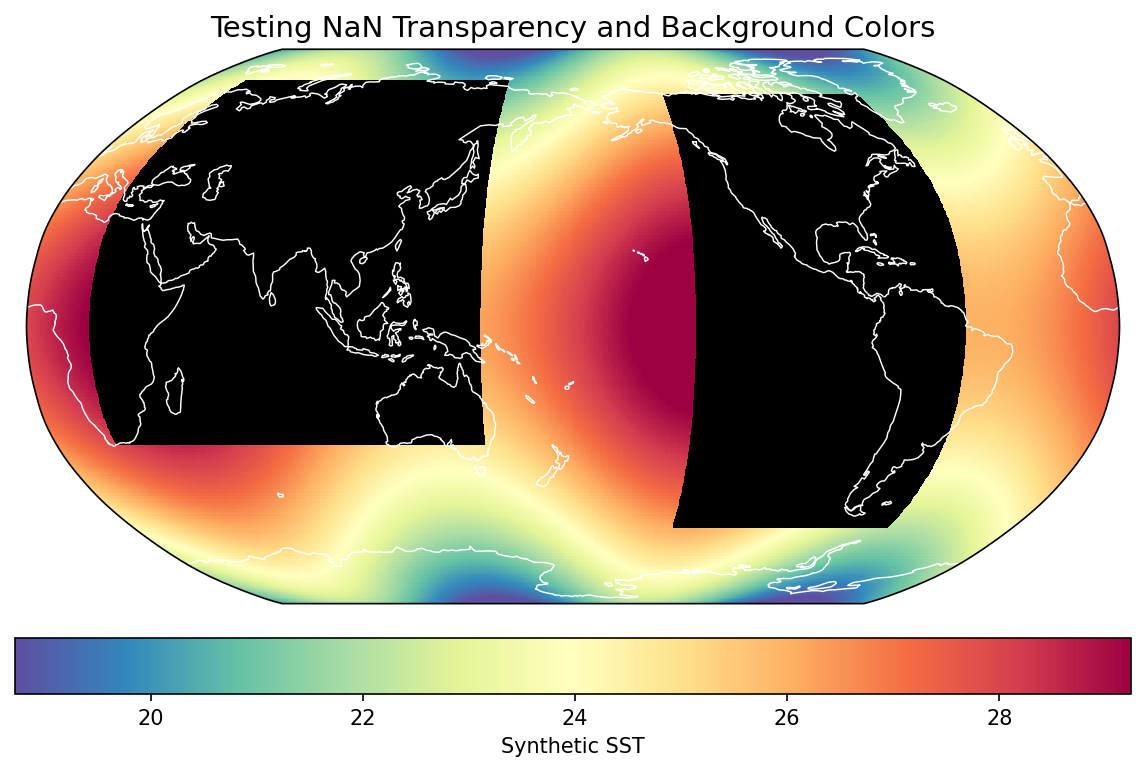

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# ============================================
# Synthetic lat/lon grid
# ============================================
lon = np.linspace(0, 360, 361)
lat = np.linspace(-90, 90, 181)

LON, LAT = np.meshgrid(lon, lat)

# ============================================
# Fake SST-like field
# ============================================
data = (
    20
    + 8*np.cos(np.deg2rad(LAT))
    + 2*np.sin(2*np.deg2rad(LON))
)

# ============================================
# Add synthetic "land" as NaNs
# ============================================
mask = (
    ((LON > 220) & (LON < 310) & (LAT > -60) & (LAT < 70))
    | ((LON > 20) & (LON < 150) & (LAT > -35) & (LAT < 75))
)

data = data.astype(float)
data[mask] = np.nan

# ============================================
# Robust color limits
# ============================================
valid = data[np.isfinite(data)]

vmin = np.percentile(valid, 2)
vmax = np.percentile(valid, 98)

# ============================================
# Colormap
# ============================================
cmap = plt.cm.Spectral_r.copy()

# NaNs transparent
cmap.set_bad(color=(0, 0, 0, 0))

# ============================================
# Projection
# ============================================
proj = ccrs.Robinson(central_longitude=180)

fig = plt.figure(figsize=(12, 6), dpi=150)
ax = plt.axes(projection=proj)

ax.set_global()

# ============================================
# TRY DIFFERENT BACKGROUNDS HERE
# ============================================

# Black background
ax.set_facecolor("black")

# Uncomment these to test alternatives:
# ax.set_facecolor("white")
# ax.set_facecolor("lime")
# ax.set_facecolor("midnightblue")

# ============================================
# Plot
# ============================================
pcm = ax.pcolormesh(
    LON,
    LAT,
    data,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    shading="nearest",
    vmin=vmin,
    vmax=vmax,
    rasterized=True
)

# ============================================
# Coastlines
# ============================================
ax.coastlines(color="white", linewidth=0.7)

# ============================================
# Colorbar
# ============================================
cbar = plt.colorbar(
    pcm,
    orientation="horizontal",
    pad=0.05,
    shrink=0.8
)

cbar.set_label("Synthetic SST")

# ============================================
# Title
# ============================================
ax.set_title(
    "Testing NaN Transparency and Background Colors",
    fontsize=14
)

plt.show()

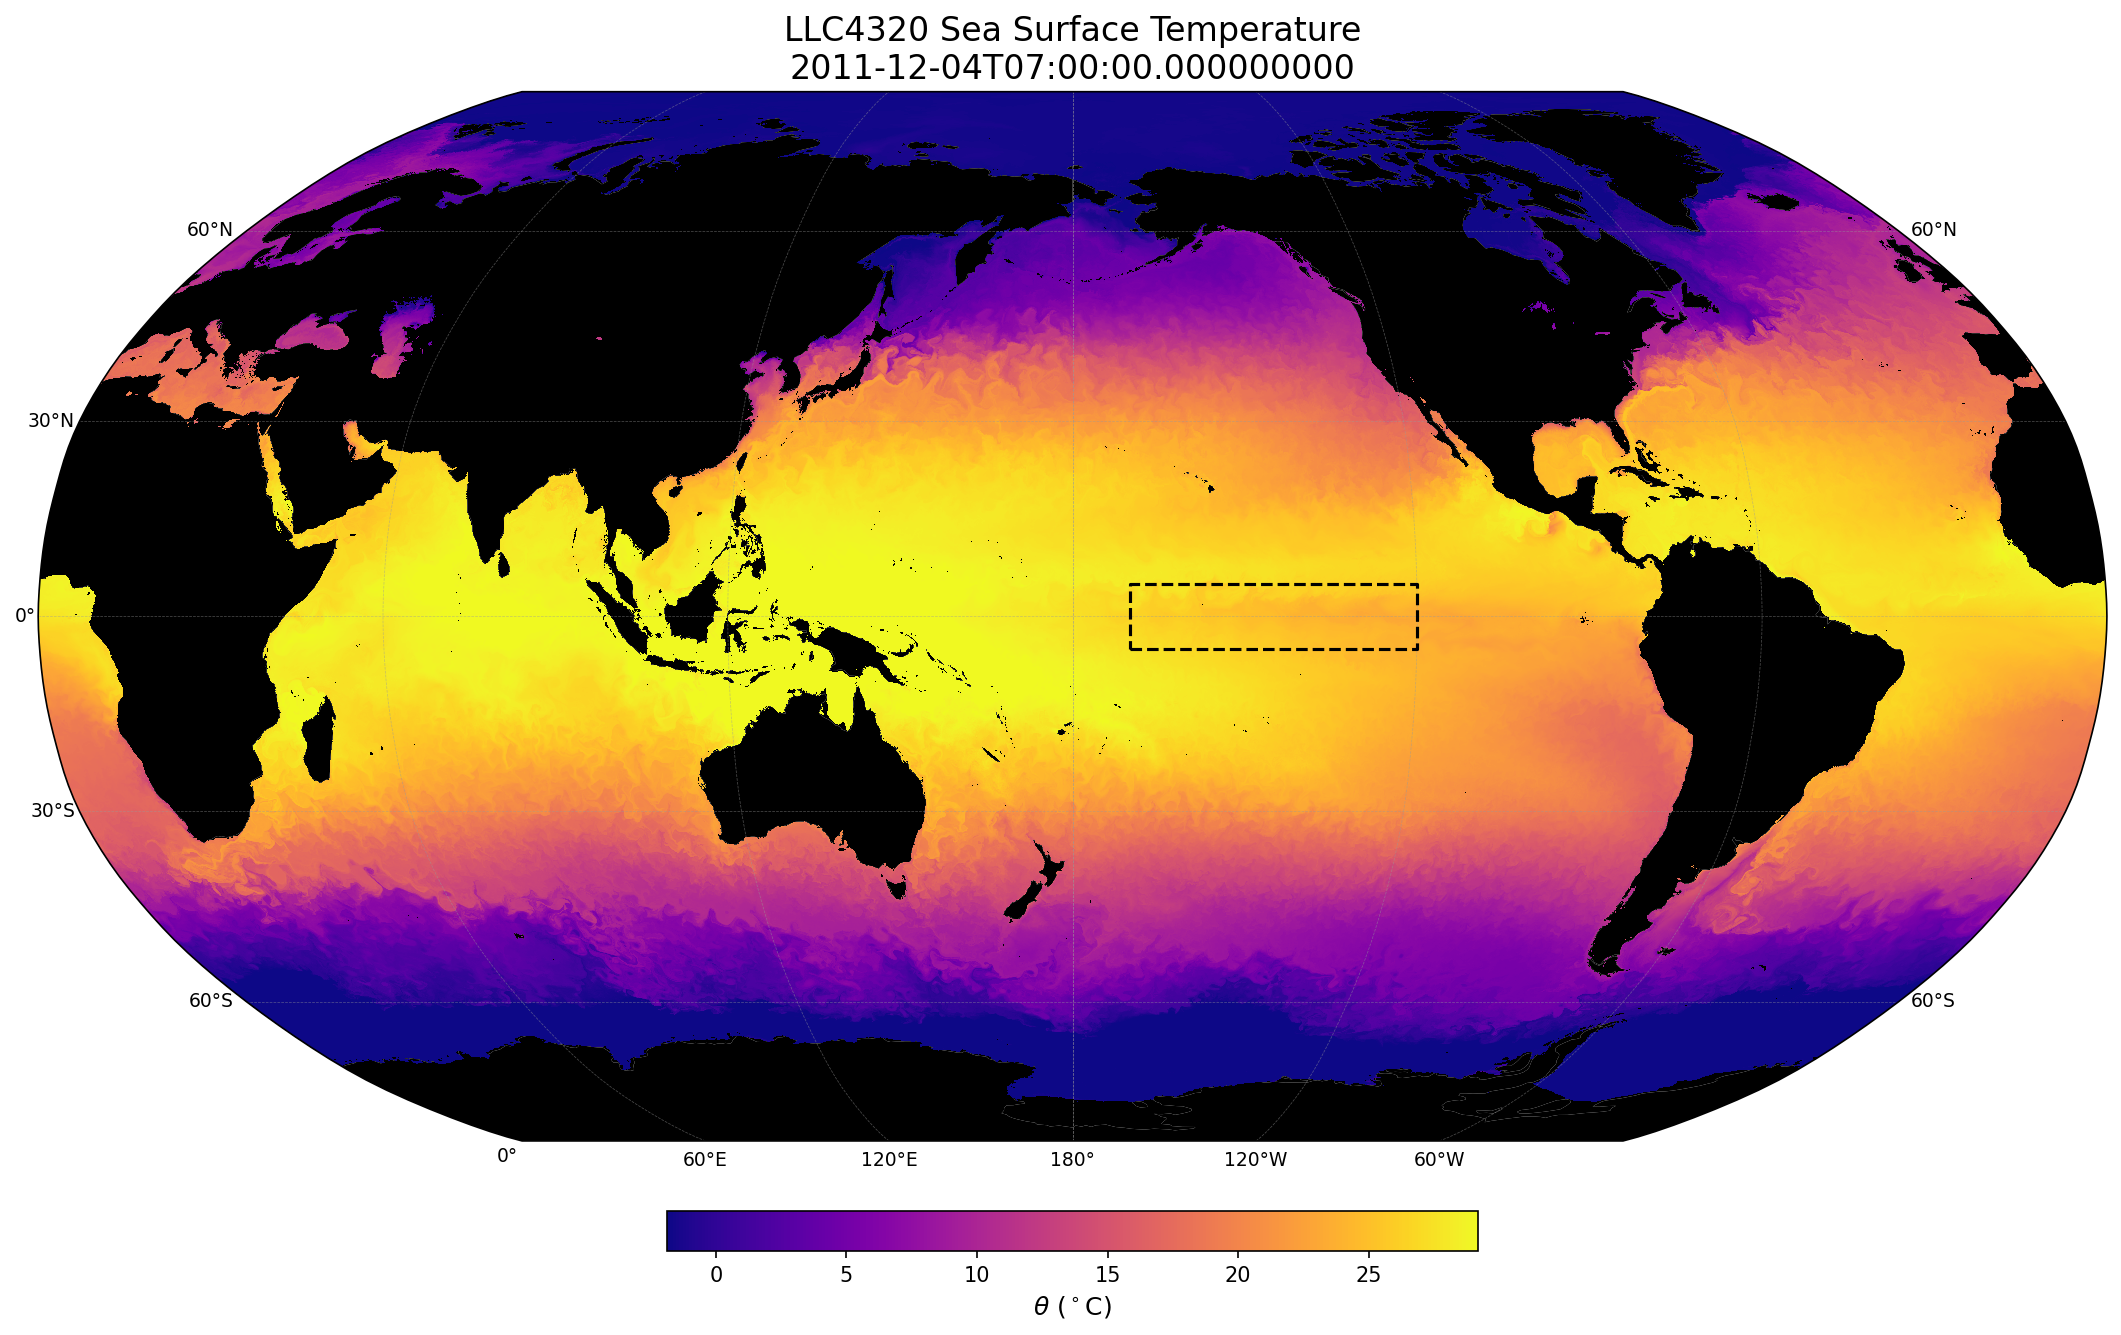

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ============================================
# Toggle variable here — only line to change
# ============================================
plot_var = "Theta"

# ============================================
# Select timestep and surface level
# ============================================
if plot_var == "Eta":
    llc_sub = llc.isel(time=1975)
else:
    llc_sub = llc.isel(time=1975, k=0)

# ============================================
# Variables
# ============================================
data_var = llc_sub[plot_var]
xc = llc["XC"]
yc = llc["YC"]
mask = llc["hFacC"].isel(k=0)

# ============================================
# Data-driven color scaling
# ============================================
raw = data_var.compute().values
valid = np.isfinite(raw) & (raw != 0.0)

if plot_var == "Eta":
    vlim = float(np.nanpercentile(np.abs(raw[valid]), 98))
    norm = colors.TwoSlopeNorm(vmin=-vlim, vcenter=0.0, vmax=vlim)
    cmap = plt.cm.RdBu_r.copy()
    cbar_label = r'SSH (m)'
    title_var = 'Sea Surface Height'
else:
    vmin = float(np.nanpercentile(raw[valid], 2))
    vmax = float(np.nanpercentile(raw[valid], 98))
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.plasma.copy()
    cbar_label = r'$\theta$ ($^\circ$C)'
    title_var = 'Sea Surface Temperature'

# NaNs transparent — lets black background show through
# Must be alpha=0 or cartopy wrapping breaks
cmap.set_bad(alpha=0)

# ============================================
# Projection setup
# ============================================
proj = ccrs.Robinson(central_longitude=180)
data_crs = ccrs.PlateCarree()

# ============================================
# Figure setup
# ============================================
fig = plt.figure(figsize=(16, 9), dpi=150)
ax = plt.axes(projection=proj)
ax.set_global()

# Black background — NaN transparent cells show black underneath
ax.add_feature(cfeature.OCEAN, facecolor='black', edgecolor='none', zorder=0)
ax.add_feature(cfeature.LAND,  facecolor='black', edgecolor='none', zorder=0)

# ============================================
# Plot LLC faces
# ============================================
pcm = None

for face in range(13):

    data_face = data_var.sel(face=face)

    # Apply LLC ocean mask
    data_face = data_face.where(mask.sel(face=face) > 0)

    lon_face = xc.sel(face=face)
    lat_face = yc.sel(face=face)

    pcm = ax.pcolormesh(
        lon_face,
        lat_face,
        data_face,
        transform=data_crs,
        cmap=cmap,
        norm=norm,
        shading='auto',
        rasterized=True,
        zorder=1
    )

# ============================================
# Coastlines
# ============================================
ax.coastlines(linewidth=0.7, color='black', alpha=0, zorder=5)

# ============================================
# Gridlines
# ============================================
gl = ax.gridlines(
    crs=data_crs,
    draw_labels=True,
    linewidth=0.35,
    color='0.6',
    alpha=0.5,
    linestyle='--'
)
gl.top_labels = False
gl.right_labels = False
gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
gl.ylocator = mticker.FixedLocator(np.arange(-90, 91, 30))
gl.xlabel_style = {'size': 9, 'color': 'black'}
gl.ylabel_style = {'size': 9, 'color': 'black'}

# ============================================
# Niño 3.4 box
# ============================================
ax.plot(
    [-170, -120, -120, -170, -170],
    [-5, -5, 5, 5, -5],
    transform=data_crs,
    color='black',
    linewidth=1.5,
    linestyle="--",
    zorder=6
)

# ============================================
# Colorbar
# ============================================
cbar = fig.colorbar(
    pcm,
    ax=ax,
    orientation='horizontal',
    pad=0.06,
    shrink=0.7,
    fraction=0.035
)
cbar.set_label(cbar_label, fontsize=12)

# ============================================
# Title
# ============================================
time_str = str(llc_sub.time.values)
ax.set_title(
    f'LLC4320 {title_var}\n{time_str}',
    fontsize=16
)

plt.tight_layout()
plt.savefig("mapSSTNina1975.png", dpi=450, bbox_inches="tight")
plt.show()

<>:81: SyntaxWarning: invalid escape sequence '\c'
<>:82: SyntaxWarning: invalid escape sequence '\c'
<>:81: SyntaxWarning: invalid escape sequence '\c'
<>:82: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_2319833/2131241420.py:81: SyntaxWarning: invalid escape sequence '\c'
  ax.set_xlabel('Longitude ($^\circ$)', fontsize=12)
/tmp/ipykernel_2319833/2131241420.py:82: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel('Latitude ($^\circ$)', fontsize=12)


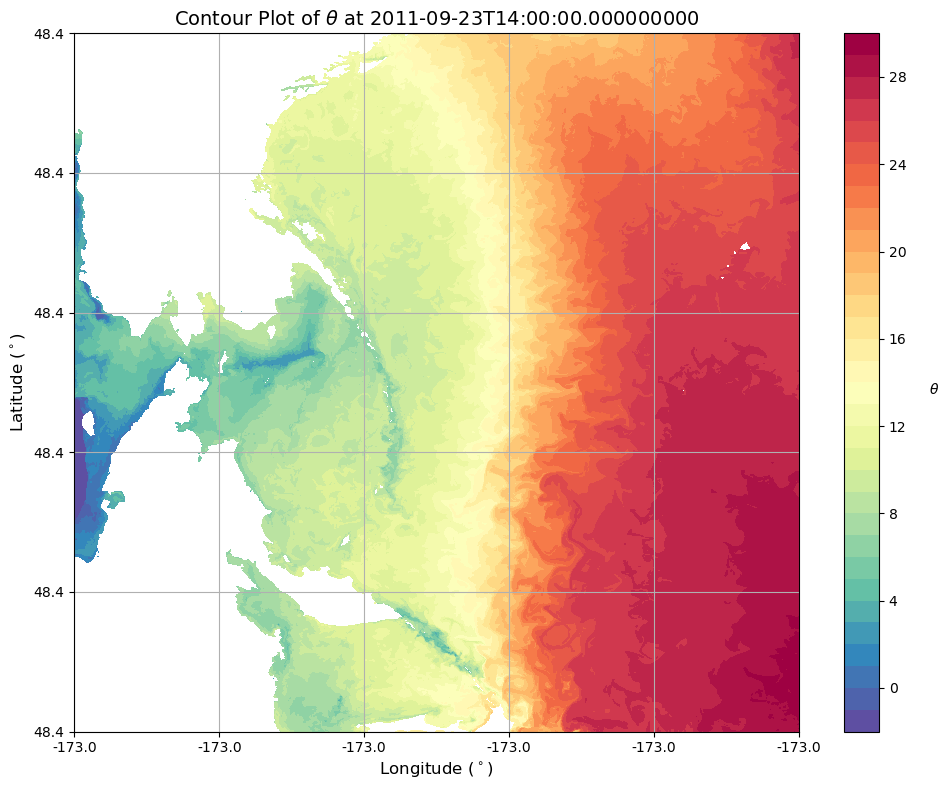

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# --------------------------------------------------
# Select LLC face/time/depth
# --------------------------------------------------
m = 7

llc_sub = llc.isel(face=m, k=0, time=254)

Theta = llc_sub['Theta']

lat = llc['YC'].sel(face=m)
lon = llc['XC'].sel(face=m)

time_str = str(llc_sub.time.values)


# --------------------------------------------------
# Plot in index space (robust)
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8))

cf = ax.contourf(
    Theta['i'],
    Theta['j'],
    Theta,
    cmap="Spectral_r",
    levels=30,
    vmin=np.min(Theta).values,
    vmax=np.max(Theta).values
)

# Colorbar
cbar = plt.colorbar(cf, ax=ax)
cbar.set_label(r'$\theta$', rotation=0, labelpad=20)


# --------------------------------------------------
# Create geographic tick labels
# --------------------------------------------------
n_ticks = 6

# Index tick positions
i_ticks = np.linspace(float(Theta['i'].min()),
                      float(Theta['i'].max()),
                      n_ticks)

j_ticks = np.linspace(float(Theta['j'].min()),
                      float(Theta['j'].max()),
                      n_ticks)

# Convert to integer indices
i_idx = np.round(i_ticks).astype(int)
j_idx = np.round(j_ticks).astype(int)

# Latitude labels from central column
lat_labels = [
    f"{lat.values[j, lat.shape[1]//2]:.1f}"
    for j in j_idx
]

# Longitude labels from central row
lon_labels = [
    f"{lon.values[lon.shape[0]//2, i]:.1f}"
    for i in i_idx
]

# Apply ticks
ax.set_xticks(i_ticks)
ax.set_yticks(j_ticks)

ax.set_xticklabels(lon_labels)
ax.set_yticklabels(lat_labels)


# --------------------------------------------------
# Labels/title
# --------------------------------------------------
ax.set_xlabel('Longitude ($^\circ$)', fontsize=12)
ax.set_ylabel('Latitude ($^\circ$)', fontsize=12)

ax.set_title(
    f'Contour Plot of $\\theta$ at {time_str}',
    fontsize=14
)

ax.grid(True)

plt.tight_layout()

plt.savefig(f'LLCFace{m}.png',
            dpi=400,
            bbox_inches='tight')

plt.show()